In [2]:
from google.colab import files
files.upload()

Saving trends_analysed.csv to trends_analysed.csv


{'trends_analysed.csv': b'post_id,title,category,score,num_comments,author,collected_at,engagement,is_popular\n47633396,Tell HN: Anthropic no longer allowing Claude Code subscriptions to use OpenClaw,technology,706,572,firloop,2026-04-04 10:24:28,0.809052333804809,True\n47637287,Some Unusual Trees,others,23,6,simplegeek,2026-04-04 10:24:28,0.25,False\n47631118,Artemis II crew take \xe2\x80\x9cspectacular\xe2\x80\x9d image of Earth,others,779,271,andsoitis,2026-04-04 10:24:28,0.3474358974358974,True\n47637228,TurboQuant model weight compression support added to Llamacpp,others,10,2,lastdong,2026-04-04 10:24:28,0.18181818181818182,False\n47629433,iNaturalist,others,430,108,bookofjoe,2026-04-04 10:24:28,0.2505800464037123,True\n47594936,GitHub has DMCA\'d nearly all forks of the official Claude-code repo,technology,11,7,cg505,2026-04-04 10:24:28,0.5833333333333334,False\n47628608,OpenClaw privilege escalation vulnerability,others,377,196,kykeonaut,2026-04-04 10:24:28,0.5185185185185185,Tr

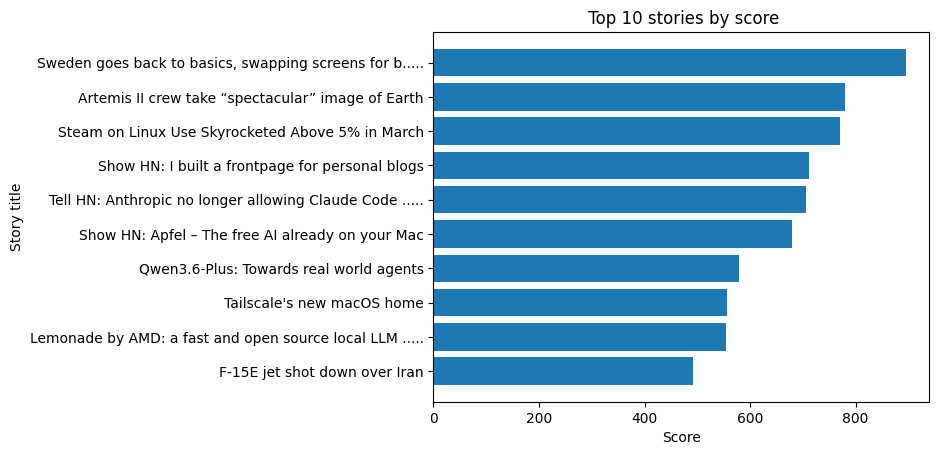

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os
# task-1
#load dataset
df=pd.read_csv("trends_analysed.csv")
os.makedirs("outputs",exist_ok=True)
#Task-2
top=df.sort_values(by="score",ascending=False).head(10)
top["short_title"]=top["title"].apply(lambda x:x[:50]+"....." if len(x)>50 else x)
plt.figure()
plt.barh(top["short_title"],top["score"])
plt.xlabel("Score")
plt.ylabel("Story title")
plt.title(" Top 10 stories by score")
plt.gca().invert_yaxis()
plt.savefig("chart1_top.png")
plt.show()


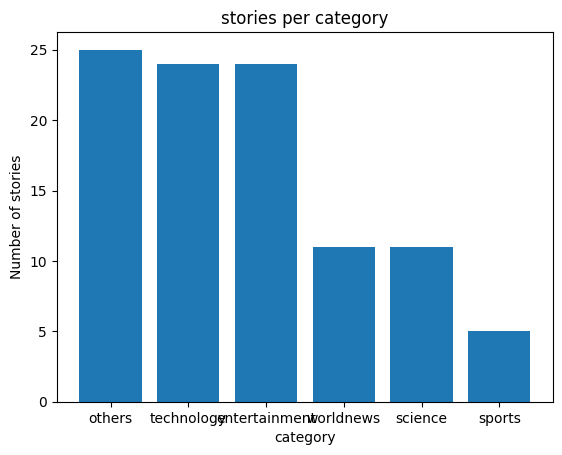

In [9]:
#task-3
counts_category=df["category"].value_counts()
plt.figure()
plt.bar(counts_category.index,counts_category.values)
plt.xlabel("category")
plt.ylabel("Number of stories")
plt.title("stories per category")
plt.savefig("chart2_category.png")

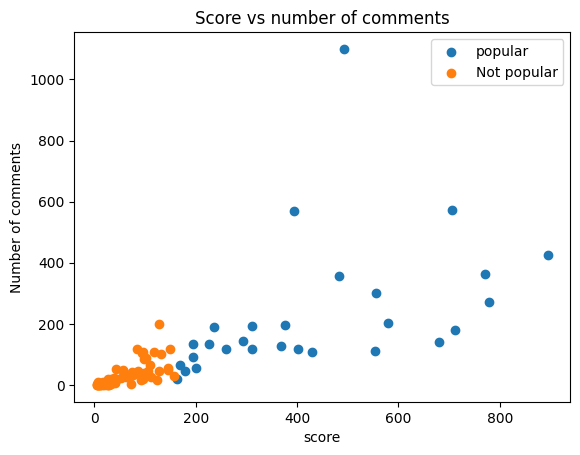

In [10]:
#task-4
popular=df[df["is_popular"]==True]
not_popular=df[df["is_popular"]==False]
plt.scatter(popular["score"],popular["num_comments"],label="popular")
plt.scatter(not_popular["score"],not_popular["num_comments"],label="Not popular")
plt.xlabel("score")
plt.ylabel("Number of comments")
plt.title("Score vs number of comments")
plt.legend()
plt.savefig("chart3_scatter.png")



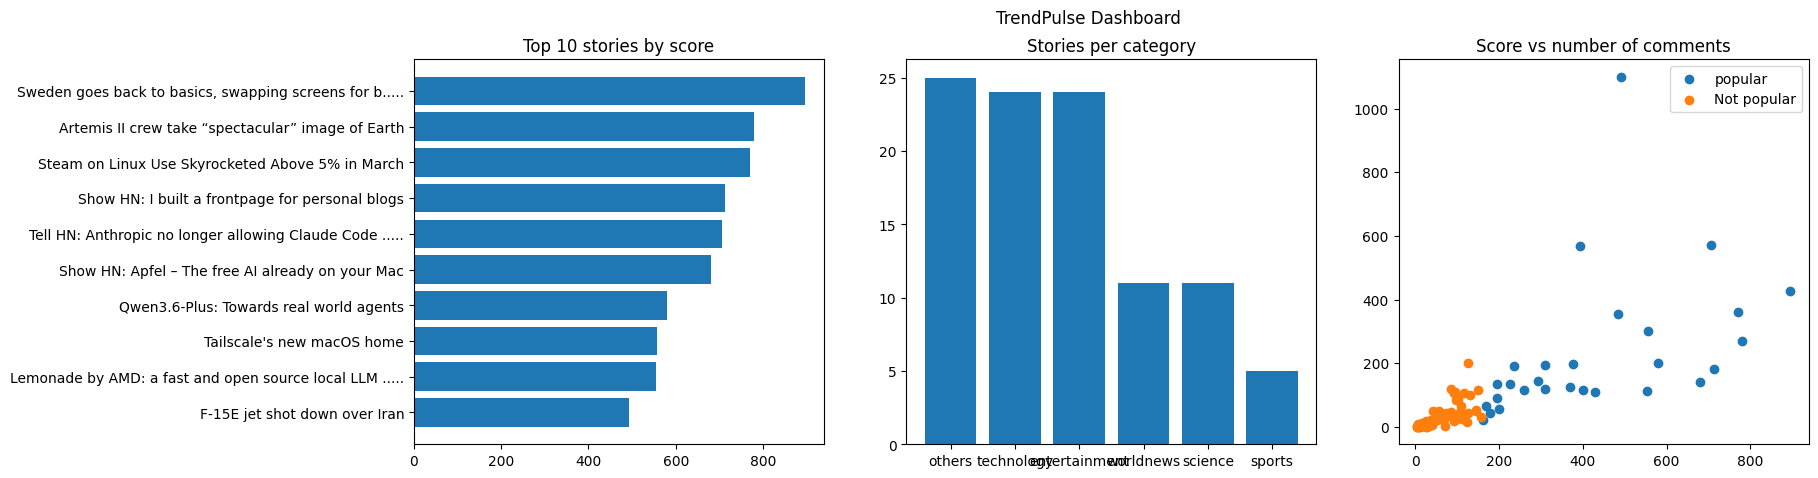

In [14]:
#task-5
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].barh(top["short_title"],top["score"])
axes[0].set_title("Top 10 stories by score")
axes[0].invert_yaxis()
axes[1].bar(counts_category.index,counts_category.values)
axes[1].set_title("Stories per category")
axes[2].scatter(popular["score"],popular["num_comments"],label="popular")
axes[2].scatter(not_popular["score"],not_popular["num_comments"],label="Not popular")
axes[2].set_title("Score vs number of comments")
axes[2].legend()
fig.suptitle("TrendPulse Dashboard")
plt.savefig("dashboard.png")
plt.show()
